# Population Step-Down: Maps and Diagnostics

Visualizes `pop_pred_final.csv` outputs on the 2011 SAL geographies. Run `tess_newpred_compute.ipynb` first.

Maps are drawn in EPSG:32735 unless noted, the growth-rate map uses EPSG:4326 for the lon/lat city annotations.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())))

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar

from src.crs import CRS_WGS84
from src.paths import CENSUS_2011_SAL, POP_PRED_FINAL

sal = gpd.read_file(CENSUS_2011_SAL)
sal_wards = pd.read_csv(POP_PRED_FINAL)

c:\Users\Tess\miniforge3\envs\south_africa\Lib\site-packages\pyogrio\core.py:38: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [3]:
# Normalize EA_CODE to plain digit strings on both sides ("123456.0" → "123456")
# to avoid dtype mismatches without integer casting that can fail.
sal["EA_CODE"] = sal["EA_CODE"].astype(str).str.strip().str.split(".").str[0]
sal_wards["EA_CODE"] = sal_wards["EA_CODE"].astype(str).str.strip().str.split(".").str[0]

sal_map = sal.merge(sal_wards, on="EA_CODE", how="left")

sal_map["dense_2023"] = sal_map["sal2023_est"] / sal_map["area_km2"]
sal_map["log_density"] = np.log1p(sal_map["dense_2023"])

print(f"Joined: {sal_map['sal2023_est'].notna().sum()} / {len(sal_map)} SALs matched")

Joined: 39168 / 39177 SALs matched


In [ ]:
# 2023 population estimate choropleth, per province, shared fixed bins.
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
bin_edges = [0, 100, 500, 1000, 2500, 5000, 10000, 15000]
cmap = mpl.cm.viridis_r

for i, prov in enumerate(sal_map["PR_NAME"].unique()):
    subset = sal_map[(sal_map["PR_NAME"] == prov) & sal_map["sal2023_est"].notna()]
    subset.plot(
        column="sal2023_est",
        cmap=cmap,
        scheme="UserDefined",
        classification_kwds={"bins": bin_edges},
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis("off")

norm = mpl.colors.BoundaryNorm(bin_edges, ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=fig.add_axes([0.48, 0.25, 0.02, 0.5]))
cbar.set_label("Population")
plt.suptitle("SAL 2023 Estimate Count")
plt.show()

In [ ]:
# Log-density quantile map, per province.
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for i, prov in enumerate(sal_map["PR_NAME"].unique()):
    subset = sal_map[sal_map["PR_NAME"] == prov].copy()
    subset.plot(column="log_density", cmap="viridis_r", legend=False,
                scheme="Quantiles", k=6, ax=axes[i])
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis("off")

norm = mpl.colors.Normalize(vmin=sal_map["log_density"].min(), vmax=sal_map["log_density"].max())
sm = mpl.cm.ScalarMappable(cmap="viridis_r", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=fig.add_axes([0.48, 0.25, 0.02, 0.5]))
cbar.set_label("Population Density (normalized) per km sq")
plt.suptitle("SAL 2023 Density (Log)")
plt.show()

In [ ]:
# Gauteng context + Johannesburg zoom.
from matplotlib.patches import Rectangle

gauteng = sal_map[sal_map["PR_NAME"].str.contains("Gauteng", case=False, na=False)].copy()
jhb = gauteng[gauteng["MN_NAME"].str.contains("Johannesburg", case=False, na=False)]

fig, axes = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [1, 2]})

gauteng.plot(column="log_density", cmap="viridis_r", legend=False,
             scheme="Quantiles", k=8, ax=axes[0])

xmin, ymin, xmax, ymax = jhb.total_bounds
pad_x, pad_y = (xmax - xmin) * 0.02, (ymax - ymin) * 0.02
axes[0].add_patch(Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2 * pad_x, (ymax - ymin) + 2 * pad_y,
    linewidth=2, edgecolor="red", facecolor="none",
))
axes[0].set_title("Gauteng (Context)", fontsize=12)
axes[0].axis("off")

jhb.plot(column="log_density", cmap="viridis_r", legend=False,
         scheme="Quantiles", k=8, ax=axes[1])
axes[1].set_title("Johannesburg Population Density", fontsize=14)
axes[1].axis("off")

norm = mpl.colors.Normalize(vmin=sal_map["log_density"].min(), vmax=sal_map["log_density"].max())
sm = mpl.cm.ScalarMappable(cmap="viridis_r", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)
cbar.set_label("Population Density (normalized) per km sq")
plt.show()

In [ ]:
# Growth-rate map with city annotations — needs lon/lat (EPSG:4326).
import matplotlib.cm as cm
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sal_map_wgs = sal_map.to_crs(CRS_WGS84)

fig, ax = plt.subplots(1, figsize=(16, 10))

vmin, vmax = sal_map_wgs["growth_rate"].min(), sal_map_wgs["growth_rate"].max()
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = cm.BrBG

# dx=111000: approx meters per degree at these latitudes
scalebar = ScaleBar(dx=111000, units="m", dimension="si-length", location="lower left")

sal_map_wgs.plot(column="growth_rate", cmap=cmap, norm=norm, legend=False, ax=ax)

axins = inset_axes(ax, width="30%", height="30%", bbox_to_anchor=(0, 0, .75, 1),
                   loc="upper right", bbox_transform=ax.transAxes)
sal_map_wgs.plot(column="growth_rate", cmap=cmap, norm=norm, legend=False, ax=axins)
axins.set_xlim(27.75, 28.50)
axins.set_ylim(-26.30, -25.70)
axins.scatter(28.0934, -25.9075, color="black", s=5, zorder=20)
axins.text(28.0934 + 0.02, -25.9075 + 0.05, "Olievenhoutbosch", fontsize=9, ha="left")
axins.set_xticks([])
axins.set_yticks([])
axins.set_title("Johannesburg / Pretoria", fontsize=8)

axins2 = inset_axes(ax, width="30%", height="30%", loc="lower left",
                    bbox_to_anchor=(0.01, 0.05, 1, 1), bbox_transform=ax.transAxes)
sal_map_wgs.plot(column="growth_rate", cmap=cmap, norm=norm, legend=False, ax=axins2)
axins2.set_xlim(30.85, 31.20)
axins2.set_ylim(-30.05, -29.65)
axins2.scatter(30.9849, -29.7280, color="black", s=5, zorder=20)
axins2.text(30.9849 + 0.01, -29.7280 + 0.01, "KwaMashu", fontsize=8, ha="left")
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_title("Durban", fontsize=8)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", "0", f"{vmax:.2f}"])
cbar.set_label("Growth Rate")

for lng, lat, label, dx, dy in [
    (28.0473, -26.2041, "Johannesburg", -0.08, 0.05),
    (28.2293, -25.7479, "Pretoria", -0.03, 0.05),
    (31.0218, -29.8587, "Durban", 0.02, 0.0),
    (30.9849, -29.7280, "KwaMashu", -0.02, 0.13),
]:
    ax.scatter(lng, lat, color="black", s=5, zorder=20)
    ax.text(lng + dx, lat + dy, label, fontsize=9)

ax.set_title("SAL Annual Growth Rate (2011–2023)")
ax.set_axis_off()
ax.add_artist(scalebar)
plt.show()

,EA_TYPE,pop2011,pop2023,growth_rate_2011_2023
0,Collective living quarters,341906.3,2.653690e+05,-2.089654
1,Commercial,354777.5,2.653699e+05,-2.390679
2,Farms,465265.7,4.461940e+05,-0.348182
3,Formal residential,8070637.5,7.590670e+06,-0.509635
4,Industrial,209060.4,1.917371e+05,-0.718225
5,Informal residential,1854216.1,2.407169e+06,2.198735
6,Parks and recreation,22181.7,1.658538e+04,-2.393769
7,Small holdings,282146.9,3.050724e+05,0.653134
8,Township,7695385.7,9.821068e+06,2.053372
9,Traditional residential,5170932.2,5.928200e+06,1.145407


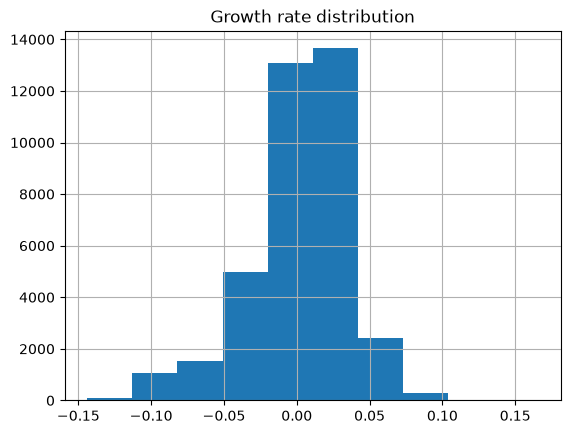

WardID                 74804019
EA_CODE                76610107
sal2011_pop               108.0
ward2023_pop               1444
EA_GTYPE                  Urban
EA_TYPE              Industrial
econ_status     Non_Residential
houses2011                133.0
Black_Afri                103.0
White                       5.0
Coloured                    0.0
Indian_or                   0.0
Other                       0.0
area_km2              21.188181
sal_dense              5.097181
log_density            1.807827
ward2011_sum             9309.9
share2011              0.011601
dasym_weight           0.011601
sal2023_est             16.7512
growth_rate           -0.143846
Name: 1209, dtype: object


In [8]:
# Growth summary by EA type and distribution checks.
gtype_summary = sal_wards.groupby("EA_TYPE").agg(
    pop2011=("sal2011_pop", "sum"),
    pop2023=("sal2023_est", "sum"),
).reset_index()
gtype_summary["growth_rate_2011_2023"] = (
    ((gtype_summary["pop2023"] / gtype_summary["pop2011"]) ** (1 / 12) - 1) * 100
)
display(gtype_summary)

sal_wards["growth_rate"].hist()
plt.title("Growth rate distribution")
plt.show()

print(sal_wards.loc[sal_wards["growth_rate"].idxmin()])